# B3 — AnoExpress cross-study context for OBPs (An. coluzzii focus)

OBPs are not canonical resistance genes. If Bouaké coluzzii OBP upregulation is absent from the AnoExpress meta-analysis, that would itself be a headline finding (PM-specific / site-specific).

In [43]:
import os, numpy as np, pandas as pd
import plotly.express as px, plotly.graph_objects as go
import anoexpress as ae

obp_col = pd.read_csv("results/abc_obp/bouake_de_obp_coluzzii.csv")
print("Bouaké DE OBPs (coluzzii):", obp_col.shape)
print("significant padj<0.05:", int((obp_col["padj"] < 0.05).sum()))

fc = ae.data(data_type="fcs", analysis="gamb_colu")
bouake_cols = [c for c in fc.columns if "Bouake" in c]
other_cols = [c for c in fc.columns if c not in bouake_cols]

meta = pd.DataFrame({
    "median_fc": fc[other_cols].median(axis=1),
    "mean_fc":   fc[other_cols].mean(axis=1),
    "n_up_p05":  (fc[other_cols] > 0).sum(axis=1),
    "n_dn_p05":  (fc[other_cols] < 0).sum(axis=1),
    "n_studies": fc[other_cols].notna().sum(axis=1),
}).reset_index().rename(columns={"index":"GeneID"})
meta["bouake_gamb_unexp"] = fc["Bouake_gamb_unexp_v_Kisumu"].values
meta["bouake_colu_unexp"] = fc["Bouake_colu_unexp_v_Ngousso"].values

obp_merge = obp_col.merge(meta, on="GeneID", how="left")
obp_merge["in_meta"] = obp_merge["median_fc"].notna()
obp_merge["meta_up_consistent"] = obp_merge["median_fc"] > 0.5
obp_merge["bouake_sig_up"] = (obp_merge["padj"] < 0.05) & (obp_merge["log2FoldChange"] > 0)

def classify(r):
    if not r["in_meta"]: return "not in AnoExpress"
    if r["bouake_sig_up"] and r["meta_up_consistent"]: return "shared candidate (Bouaké + meta up)"
    if r["bouake_sig_up"] and not r["meta_up_consistent"]: return "Bouaké novel (up here, flat/down in meta)"
    if not r["bouake_sig_up"] and r["meta_up_consistent"]: return "meta-only (not sig in Bouaké)"
    return "neither"
obp_merge["class"] = obp_merge.apply(classify, axis=1)
print(obp_merge["class"].value_counts())

Bouaké DE OBPs (coluzzii): (74, 16)
significant padj<0.05: 17


class
neither                                      30
meta-only (not sig in Bouaké)                16
not in AnoExpress                            12
Bouaké novel (up here, flat/down in meta)    11
shared candidate (Bouaké + meta up)           5
Name: count, dtype: int64


In [44]:
# ae.load_candidates — OBP ranking across meta
cand_obp = ae.load_candidates(analysis="gamb_colu", query_annotation="PBP_GOBP", func=np.nanmedian)
print("AnoExpress OBP candidates (top 10):")
print(cand_obp.head(10).to_string(index=False))

cand_obp_ren = cand_obp.rename(columns={
    "median log2 Fold Change": "ae_median_log2FC",
    "median Fold Change": "ae_median_FC",
})[["GeneID","ae_median_log2FC","ae_median_FC"]]

obp_joined = obp_merge.merge(cand_obp_ren, on="GeneID", how="left")
obp_joined["in_ae_candidates"] = obp_joined["ae_median_log2FC"].notna()
obp_joined["shared_hit"] = (obp_joined["padj"]<0.05) & (obp_joined["log2FoldChange"]>0) & (obp_joined["in_ae_candidates"]) & (obp_joined["ae_median_log2FC"]>0)

final_cols = ["GeneID","GeneName","log2FoldChange","padj","pfam_domains",
              "median_fc","n_up_p05","n_studies","ae_median_log2FC",
              "in_ae_candidates","shared_hit","class"]
obp_joined[final_cols].to_csv("results/abc_obp/bouake_obp_coluzzii_vs_anoexpress.csv", index=False)
print("\nShared OBP candidates (sig-up in Bouaké + positive in meta):",
      int(obp_joined["shared_hit"].sum()))

AnoExpress OBP candidates (top 10):
    GeneID GeneName                                             GeneDescription  median log2 Fold Change  median Fold Change
AGAP012325    OBP28 odorant-binding protein 28 [Source:VB Community Annotation]                    1.170                2.25
AGAP000278     OBP9  odorant-binding protein 9 [Source:VB Community Annotation]                    1.065                2.09
AGAP006368    Obp69  odorant-bnding protein 69 [Source:VB Community Annotation]                    0.930                1.91
AGAP004433    OBP19 odorant-binding protein 19 [Source:VB Community Annotation]                    0.840                1.79
AGAP012331    OBP29 odorant-binding protein 29 [Source:VB Community Annotation]                    0.720                1.65
AGAP012320    OBP25 odorant-binding protein 25 [Source:VB Community Annotation]                    0.720                1.65
AGAP003306     OBP2  odorant-binding protein 2 [Source:VB Community Annotation]          

In [45]:
print("shared OBP candidates:")
print(obp_joined[obp_joined["shared_hit"]][["GeneID","GeneName","log2FoldChange","padj","ae_median_log2FC"]].to_string(index=False))

shared OBP candidates:
    GeneID GeneName  log2FoldChange         padj  ae_median_log2FC
AGAP009629     OBP5        1.714811 7.427305e-12             0.235
AGAP029062      NaN        1.613284 2.540802e-11             0.310
AGAP001409     OBP3        1.576134 4.642937e-11             0.180
AGAP003306     OBP2        1.542303 2.009396e-06             0.640
AGAP010489     OBP4        1.418422 1.501135e-10             0.070
AGAP002905    OBP13        1.014557 1.509306e-02             0.265
AGAP001556     OBP7        0.958555 2.043416e-05             0.420
AGAP003530     OBP6        0.934519 1.330286e-02             0.125
AGAP002556    Obp66        0.887563 1.656506e-06             0.145
AGAP005208    OBP20        0.839407 1.516236e-03             0.245


/var/folders/yd/tz1zj4195ybgmg97z4y695w40000gp/T/ipykernel_20722/3865287323.py:56: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image("figures_ms/b3_obp_bouake_vs_anoexpress.png", scale=2)


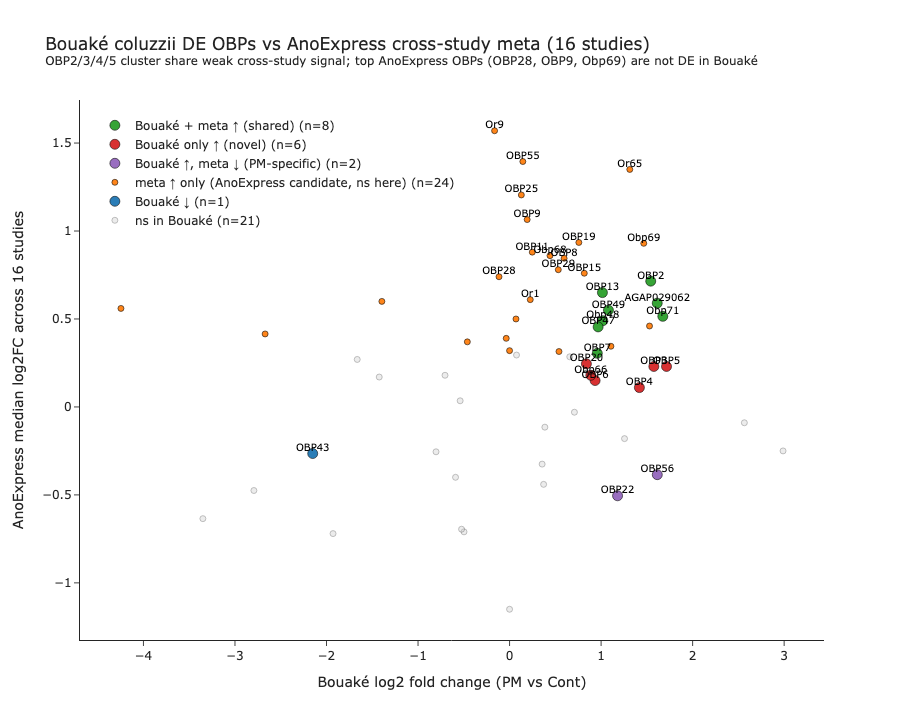

In [46]:
# Bouaké coluzzii OBP log2FC vs AnoExpress meta median — quadrant scatter
d = obp_joined[obp_joined["in_meta"]].copy()
d["label"] = np.where(d["GeneName"].isna(), d["GeneID"], d["GeneName"].astype(str))

def quadrant(r):
    if r["padj"] < 0.05 and r["log2FoldChange"] > 0:
        return "Bouaké + meta ↑ (shared)" if r["median_fc"] > 0.3 else (
               "Bouaké only ↑ (novel)"   if r["median_fc"] >= -0.3 else
               "Bouaké ↑, meta ↓ (PM-specific)")
    if r["padj"] < 0.05 and r["log2FoldChange"] < 0:
        return "Bouaké ↓"
    if (r["padj"] >= 0.05 or pd.isna(r["padj"])) and r["median_fc"] > 0.3:
        return "meta ↑ only (AnoExpress candidate, ns here)"
    return "ns in Bouaké"
d["quadrant"] = d.apply(quadrant, axis=1)

colmap = {
    "Bouaké + meta ↑ (shared)":                   "#2ca02c",
    "Bouaké only ↑ (novel)":                      "#d62728",
    "Bouaké ↑, meta ↓ (PM-specific)":             "#9467bd",
    "meta ↑ only (AnoExpress candidate, ns here)":"#ff7f0e",
    "Bouaké ↓":                                   "#1f77b4",
    "ns in Bouaké":                               "#d0d0d0",
}

fig = go.Figure()
for k, c in colmap.items():
    s = d[d["quadrant"] == k]
    fig.add_trace(go.Scatter(
        x=s["log2FoldChange"], y=s["median_fc"], mode="markers",
        name=f"{k} (n={len(s)})",
        marker=dict(size=10 if "ns" not in k else 6, color=c,
                    opacity=0.4 if k=="ns in Bouaké" else 0.95,
                    line=dict(color="black", width=0.6)),
        text=s["label"],
        customdata=s[["GeneID","padj","n_up_p05","n_studies"]].values,
        hovertemplate="<b>%{text}</b><br>%{customdata[0]}<br>Bouaké log2FC: %{x:.2f} (padj %{customdata[1]:.2e})<br>Meta median FC: %{y:.2f} (%{customdata[2]}/%{customdata[3]} studies up)<extra></extra>",
    ))
# Label interesting OBPs
label_set = d[((d["padj"]<0.05)&(d["log2FoldChange"].abs()>0.8)) | (d["median_fc"]>0.6)]
fig.add_trace(go.Scatter(
    x=label_set["log2FoldChange"], y=label_set["median_fc"], mode="text",
    text=label_set["label"], textposition="top center",
    textfont=dict(size=10, color="black"), showlegend=False, hoverinfo="skip",
))
fig.add_hline(y=0, line_color="grey", line_dash="dot")
fig.add_vline(x=0, line_color="grey", line_dash="dot")
fig.update_layout(
    title="Bouaké coluzzii DE OBPs vs AnoExpress cross-study meta (16 studies)<br><sup>OBP2/3/4/5 cluster share weak cross-study signal; top AnoExpress OBPs (OBP28, OBP9, Obp69) are not DE in Bouaké</sup>",
    xaxis_title="Bouaké log2 fold change (PM vs Cont)",
    yaxis_title="AnoExpress median log2FC across 16 studies",
    template="simple_white", width=1050, height=720,
    legend=dict(x=0.02, y=0.98, bgcolor="rgba(255,255,255,0.8)"),
)
fig.write_html("figures_ms/b3_obp_bouake_vs_anoexpress.html")
fig.write_image("figures_ms/b3_obp_bouake_vs_anoexpress.png", scale=2)
fig.show()

/var/folders/yd/tz1zj4195ybgmg97z4y695w40000gp/T/ipykernel_20722/1964712603.py:47: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image("figures_ms/b3_obp_strip.png", scale=2)


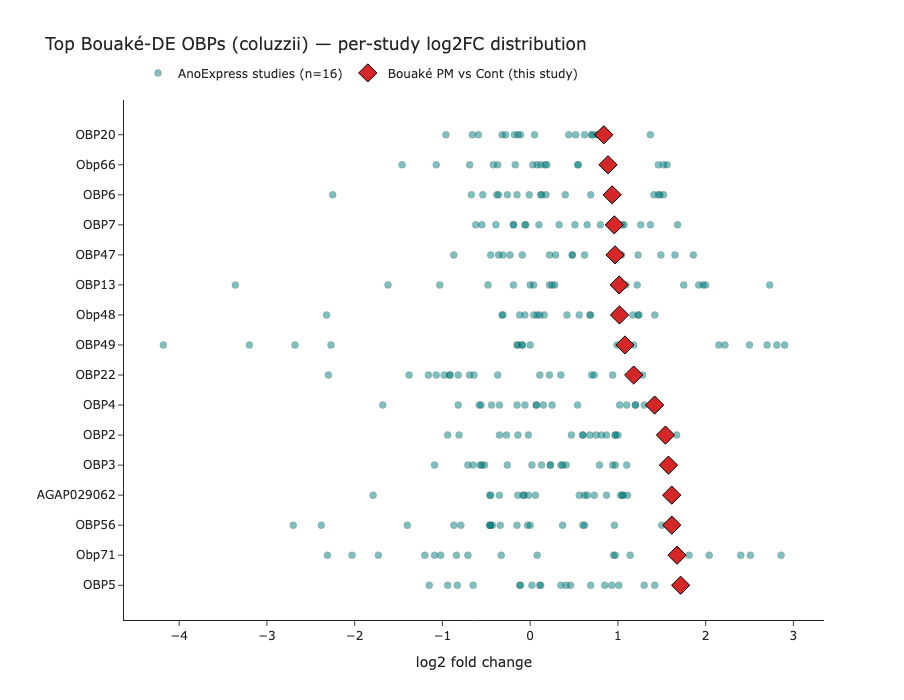

In [48]:
# Strip plot of per-study log2FC for top Bouaké-sig OBPs
obp_sig = obp_joined[obp_joined["bouake_sig_up"]].sort_values("log2FoldChange", ascending=False).head(20)
top_ids = obp_sig["GeneID"].tolist()
sub = fc.loc[[g for g in top_ids if g in fc.index]].copy()
sub["GeneID"] = sub.index
long = sub.melt(id_vars="GeneID", var_name="study", value_name="log2FC")

bouake_pm = obp_sig.set_index("GeneID").loc[[g for g in top_ids if g in sub.index], ["GeneName","log2FoldChange"]]
bouake_pm_long = bouake_pm.reset_index().assign(study="Bouaké PM vs Cont (this study)").rename(columns={"log2FoldChange":"log2FC"})[["GeneID","study","log2FC"]]
long2 = pd.concat([long, bouake_pm_long], ignore_index=True)

label_map = bouake_pm.reset_index().set_index("GeneID")["GeneName"].to_dict()
long2["label"] = long2["GeneID"].map(lambda g: label_map.get(g) if isinstance(label_map.get(g), str) else g)
gene_order = bouake_pm.reset_index().sort_values("log2FoldChange", ascending=True)["GeneID"].tolist()
long2["label"] = pd.Categorical(
    long2["label"],
    categories=[label_map.get(g) if isinstance(label_map.get(g), str) else g for g in gene_order],
    ordered=True,
)
long2["is_bouake"] = long2["study"].str.contains("Bouaké PM")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=long2.loc[~long2["is_bouake"],"log2FC"],
    y=long2.loc[~long2["is_bouake"],"label"],
    mode="markers",
    name=f"AnoExpress studies (n={len(other_cols)})",
    marker=dict(size=7, color="teal", opacity=0.5, line=dict(color="black",width=0.3)),
    hovertext=long2.loc[~long2["is_bouake"],"study"],
    hovertemplate="%{hovertext}<br>log2FC: %{x:.2f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=long2.loc[long2["is_bouake"],"log2FC"],
    y=long2.loc[long2["is_bouake"],"label"],
    mode="markers",
    name="Bouaké PM vs Cont (this study)",
    marker=dict(size=14, color="#d62728", symbol="diamond", line=dict(color="black",width=1)),
))
fig.add_vline(x=0, line_color="grey", line_dash="dot")
fig.update_layout(
    title="Top Bouaké-DE OBPs (coluzzii) — per-study log2FC distribution",
    xaxis_title="log2 fold change", yaxis_title="",
    template="simple_white", width=1000, height=700,
    legend=dict(x=0.02, y=1.08, orientation="h"),
)
fig.write_html("figures_ms/b3_obp_strip.html")
fig.write_image("figures_ms/b3_obp_strip.png", scale=2)
fig.show()